<a href="https://colab.research.google.com/github/suwimana-dev/Life_Prognosis_System/blob/master/LULC_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Land use Mapping using OpenStreetMap datasets and Google Earth Engine.**

### **Extracting the roads in Kigali using OSM**

In [ ]:
try:
  import osmnx as ox
except:
  !pip install osmnx --upgrade --quiet
  import osmnx as ox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.3/101.3 kB 2.8 MB/s eta 0:00:00


In [ ]:
print(ox.__version__)

2.0.5


In [ ]:
# extracting roads from open street map
# Download road networks
roads = ox.graph_from_place('Kigali, Rwanda', network_type='drive_service')
roads_gdf = ox.graph_to_gdfs(roads, nodes=False, edges=True)

In [ ]:
roads_gdf.head()

osmid    highway lanes maxspeed         name  \
u         v          key                                                    
279244409 1223002713 0    25796180  secondary     2       40  KG 4 Avenue   
          279244410  0    25796316  secondary     2       40          NaN   
279244410 1223002644 0    25796316  secondary     2       40          NaN   
279244411 2113511216 0    25796316  secondary     2       40          NaN   
279244419 1224173451 0    25796316  secondary     2       40          NaN   

                          oneway reversed     length    junction  \
u         v          key                                           
279244409 1223002713 0      True    False  15.542890         NaN   
          279244410  0      True    False  95.556276  roundabout   
279244410 1223002644 0      True    False  47.205114  roundabout   
279244411 2113511216 0      True    False  89.476584  roundabout   
279244419 1224173451 0      True    False  99.926566  roundabout   

                                                                   geometry  \
u         v          key                                                      
279244409 1223002713 0      LINESTRING (30.0866 -1.95387, 30.0865 -1.95377)   
          279244410  0    LINESTRING (30.0866 -1.95387, 30.08648 -1.9538...   
279244410 1223002644 0    LINESTRING (30.08575 -1.95382, 30.08555 -1.953...   
279244411 2113511216 0    LINESTRING (30.08528 -1.95405, 30.08508 -1.954...   
279244419 1224173451 0    LINESTRING (30.0854 -1.9563, 30.08569 -1.95643...   

                         access  ref bridge service width tunnel  
u         v          key                                          
279244409 1223002713 0      NaN  NaN    NaN     NaN   NaN    NaN  
          279244410  0      NaN  NaN    NaN     NaN   NaN    NaN  
279244410 1223002644 0      NaN  NaN    NaN     NaN   NaN    NaN  
279244411 2113511216 0      NaN  NaN    NaN     NaN   NaN    NaN  
279244419 1224173451 0      NaN  NaN    NaN     NaN   NaN    NaN

<Axes: >

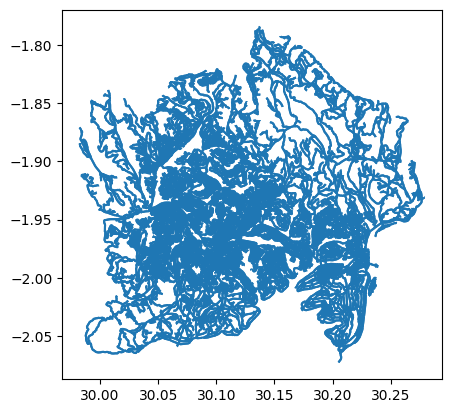

In [ ]:
roads_gdf.plot()

### **Extracting the water bodies in Rwanda using OSM**

/usr/local/lib/python3.11/dist-packages/osmnx/_overpass.py:267: UserWarning: This area is 12 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


<Axes: >

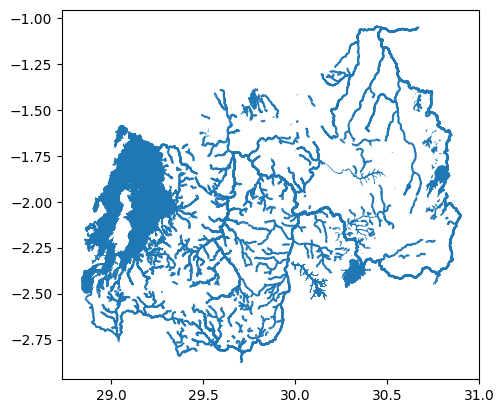

In [ ]:
# Area of interest
place_name = "Rwanda"

# Define water-related OSM tags (similar structure as building tags)
water_tags = {
    "waterway": ["river", "reservoir"],
    "natural": ["water"]
}

# Extract water features using features_from_place
water = ox.features_from_place(place_name, water_tags)

# Plot the water features
water.plot()

### **Extracting various land use in Rwanda using OSM. (This includes impervious surfaces, Cropland, Rangeland, Water bodies and Forests.)**

/usr/local/lib/python3.11/dist-packages/osmnx/_overpass.py:267: UserWarning: This area is 12 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


<Axes: >

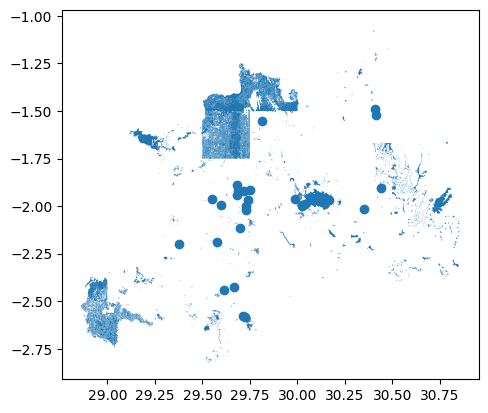

In [ ]:
landuse_tags = {
    "landuse": True  # This will retrieve all landuse tags
}

# Extract landuse polygons using features_from_place
landuse = ox.features_from_place(place_name, landuse_tags)

# Plot the landuse polygons
landuse.plot()

In [ ]:
landuse.sample(10)

geometry  \
element  id                                                              
way      1245897508  POLYGON ((29.74397 -1.58943, 29.74385 -1.58935...   
         929440408   POLYGON ((29.53682 -2.81818, 29.53706 -2.81888...   
         987837435   POLYGON ((28.98195 -2.61422, 28.98181 -2.61389...   
         994946191   POLYGON ((28.92123 -2.50059, 28.921 -2.50069, ...   
         1246170467  POLYGON ((29.65229 -1.61633, 29.65214 -1.6164,...   
relation 17270588    POLYGON ((29.71046 -1.53054, 29.70984 -1.53029...   
way      588374540   POLYGON ((29.32917 -1.70517, 29.32974 -1.70499...   
         306144631   POLYGON ((30.47048 -1.74462, 30.47066 -1.74503...   
         845165100   POLYGON ((29.06393 -2.59151, 29.06384 -2.59133...   
         1391270699  POLYGON ((30.00886 -2.05645, 30.00935 -2.05645...   

                         landuse name industrial name:en name:rw aeroway  \
element  id                                                                
way      1245897508  residential  NaN        NaN     NaN     NaN     NaN   
         929440408   residential  NaN        NaN     NaN     NaN     NaN   
         987837435   residential  NaN        NaN     NaN     NaN     NaN   
         994946191   residential  NaN        NaN     NaN     NaN     NaN   
         1246170467  residential  NaN        NaN     NaN     NaN     NaN   
relation 17270588    residential  NaN        NaN     NaN     NaN     NaN   
way      588374540         grass  NaN        NaN     NaN     NaN     NaN   
         306144631   residential  NaN        NaN     NaN     NaN     NaN   
         845165100      farmland  NaN        NaN     NaN     NaN     NaN   
         1391270699     farmland  NaN        NaN     NaN     NaN     NaN   

                    military operator operator:type  ... capacity informal  \
element  id                                          ...                     
way      1245897508      NaN      NaN           NaN  ...      NaN      NaN   
         929440408       NaN      NaN           NaN  ...      NaN      NaN   
         987837435       NaN      NaN           NaN  ...      NaN      NaN   
         994946191       NaN      NaN           NaN  ...      NaN      NaN   
         1246170467      NaN      NaN           NaN  ...      NaN      NaN   
relation 17270588        NaN      NaN           NaN  ...      NaN      NaN   
way      588374540       NaN      NaN           NaN  ...      NaN      NaN   
         306144631       NaN      NaN           NaN  ...      NaN      NaN   
         845165100       NaN      NaN           NaN  ...      NaN      NaN   
         1391270699      NaN      NaN           NaN  ...      NaN      NaN   

                    population highway substation place_of_worship  \
element  id                                                          
way      1245897508        NaN     NaN        NaN              NaN   
         929440408         NaN     NaN        NaN              NaN   
         987837435         NaN     NaN        NaN              NaN   
         994946191         NaN     NaN        NaN              NaN   
         1246170467        NaN     NaN        NaN              NaN   
relation 17270588          NaN     NaN        NaN              NaN   
way      588374540         NaN     NaN        NaN              NaN   
         306144631         NaN     NaN        NaN              NaN   
         845165100         NaN     NaN        NaN              NaN   
         1391270699        NaN     NaN        NaN              NaN   

                    opening_hours product          type plants  
element  id                                                     
way      1245897508           NaN     NaN           NaN    NaN  
         929440408            NaN     NaN           NaN    NaN  
         987837435            NaN     NaN           NaN    NaN  
         994946191            NaN     NaN           NaN    NaN  
         1246170467           NaN     NaN           NaN    NaN  
relation 17270588          

In [ ]:
landuse.landuse.unique()

array(['basin', 'industrial', 'greenfield', 'forest', 'military',
       'quarry', 'residential', 'cemetery', 'farmland', 'orchard',
       'commercial', 'meadow', 'reservoir', 'education', 'landfill',
       'grass', 'religious', 'recreation_ground', 'utility',
       'agriculture', 'farmyard', 'construction', 'village_green',
       'kitchen garden', 'retail', 'allotments', 'garages', 'brownfield',
       'institutional', 'churchyard', 'school', 'harbour', 'healthcare',
       'aquaculture', 'greenhouse_horticulture', 'greenery'], dtype=object)

**Filtering the generated land use categories to remain with relevant categories**

In [ ]:
import folium
import geopandas as gpd

# STEP 1: Filter landuse types
allowed_landuses = [
    'basin', 'industrial', 'greenfield', 'forest', 'military',
       'quarry', 'residential', 'cemetery', 'farmland', 'orchard',
       'commercial', 'meadow', 'reservoir', 'education', 'landfill',
       'grass', 'religious', 'recreation_ground', 'utility',
       'agriculture', 'farmyard', 'construction', 'village_green',
       'kitchen garden', 'retail', 'allotments', 'garages', 'brownfield',
       'institutional', 'churchyard', 'school', 'harbour', 'healthcare',
       'aquaculture', 'greenhouse_horticulture', 'greenery'
]

excluded_landuses = [
    'military', 'religious', 'construction',
    'retail',
]

# Filter to include only desired landuse types
filtered_landuse = landuse[
    landuse['landuse'].isin(allowed_landuses) &
    ~landuse['landuse'].isin(excluded_landuses)
]

# STEP 2: Filter only polygon/multipolygon geometries
filtered_landuse = filtered_landuse[filtered_landuse.geometry.type.isin(['Polygon', 'MultiPolygon'])]
filtered_landuse = filtered_landuse[filtered_landuse.area > 0]

# STEP 3: Reproject to UTM
utm = filtered_landuse.estimate_utm_crs()
filtered_landuse = filtered_landuse.to_crs(utm)

# Clean invalid geometries while still in projected CRS
filtered_landuse = filtered_landuse[filtered_landuse.is_valid & ~filtered_landuse.is_empty]

# Reproject back to WGS84 for Folium
filtered_landuse = filtered_landuse.to_crs(epsg=4326)

# STEP 4: Compute map center AFTER returning to WGS84
map_center = [
    filtered_landuse.geometry.centroid.y.mean(),
    filtered_landuse.geometry.centroid.x.mean()
]

# Reproject back to WGS84 for Folium mapping
filtered_landuse = filtered_landuse.to_crs(epsg=4326)

# Clean invalid/empty geometries
filtered_landuse = filtered_landuse[filtered_landuse.is_valid & ~filtered_landuse.is_empty]

# STEP 5: Define simple color map
landuse_colors = {
    'residential': 'lightblue',
    'industrial': 'darkgrey',
    'quarry': 'black',
    'cemetery': 'darkgrey',
    'forest': 'green',
    'landfill': 'black',
    'grass': 'lightgreen',
    'farmland': 'orange',
    'meadow': 'yellowgreen',
    'commercial': 'red',
    'reservoir': 'blue',
    'education': 'purple',
    'recreation_ground': 'lightgreen',
    'greenfield': 'green',
    'basin': 'blue',
    'farmyard': 'orange',
    'brownfield': 'saddlebrown',
    'healthcare': 'pink',
    'agriculture': 'orange',
    'orchard': 'olive',
    'greenery': 'limegreen'
}

# STEP 6: Create interactive Folium map
m = folium.Map(location=map_center, zoom_start=12)

# STEP 7: Add each polygon to the map
for _, row in filtered_landuse.iterrows():
    landuse_type = row['landuse']
    color = landuse_colors.get(landuse_type, 'grey')

    geom = row.geometry
    if geom.geom_type == 'MultiPolygon':
        for poly in geom.geoms:
            folium.Polygon(
                locations=[(lat, lon) for lon, lat in poly.exterior.coords],
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.6,
                tooltip=f"Landuse: {landuse_type}"
            ).add_to(m)
            for interior in poly.interiors:
                folium.Polygon(
                    locations=[(lat, lon) for lon, lat in interior.coords],
                    color=color,
                    fill=True,
                    fill_color=color,
                    fill_opacity=0.6,
                    tooltip=f"Landuse: {landuse_type}"
                ).add_to(m)
    else:  # Polygon
        folium.Polygon(
            locations=[(lat, lon) for lon, lat in geom.exterior.coords],
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.6,
            tooltip=f"Landuse: {landuse_type}"
        ).add_to(m)
        for interior in geom.interiors:
            folium.Polygon(
                locations=[(lat, lon) for lon, lat in interior.coords],
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.6,
                tooltip=f"Landuse: {landuse_type}"
            ).add_to(m)

# STEP 8: Display the interactive map
folium.Marker(location=map_center, tooltip="Center of Landuse").add_to(m)
m

/tmp/ipython-input-10-2394242273.py:29: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  filtered_landuse = filtered_landuse[filtered_landuse.area > 0]
/tmp/ipython-input-10-2394242273.py:43: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  filtered_landuse.geometry.centroid.y.mean(),
/tmp/ipython-input-10-2394242273.py:44: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  filtered_landuse.geometry.centroid.x.mean()


Buffered data was truncated after reaching the output size limit.

**Grouping the remaining categories in five classes for further analysis.**

In [ ]:
import folium
import geopandas as gpd

# STEP 1: Filter landuse types
allowed_landuses = [
    'basin', 'industrial', 'greenfield', 'forest', 'military',
    'quarry', 'residential', 'cemetery', 'farmland', 'orchard',
    'commercial', 'meadow', 'reservoir', 'education', 'landfill',
    'grass', 'religious', 'recreation_ground', 'utility',
    'agriculture', 'farmyard', 'construction', 'village_green',
    'kitchen garden', 'retail', 'allotments', 'garages', 'brownfield',
    'institutional', 'churchyard', 'school', 'harbour', 'healthcare',
    'aquaculture', 'greenhouse_horticulture', 'greenery'
]

excluded_landuses = [
    'military', 'construction', 'churchyard', 'harbour',
    'retail', 'allotments'
]

filtered_landuse = landuse[
    landuse['landuse'].isin(allowed_landuses) &
    ~landuse['landuse'].isin(excluded_landuses)
]

# STEP 2: Keep only polygon geometries and valid shapes
filtered_landuse = filtered_landuse[filtered_landuse.geometry.type.isin(['Polygon', 'MultiPolygon'])]
filtered_landuse = filtered_landuse[filtered_landuse.area > 0]
filtered_landuse = filtered_landuse[filtered_landuse.is_valid & ~filtered_landuse.is_empty]

# STEP 3: Reproject for accurate centroid calculation
utm = filtered_landuse.estimate_utm_crs()
filtered_landuse = filtered_landuse.to_crs(utm)

# STEP 4: Reproject back to WGS84 for mapping
filtered_landuse = filtered_landuse.to_crs(epsg=4326)

# Compute map center in degrees
map_center = [
    filtered_landuse.geometry.centroid.y.mean(),
    filtered_landuse.geometry.centroid.x.mean()
]

# STEP 5: Define landuse group mappings ['Impervious-Surface', 'Cropland', 'Forest', 'Rangeland', 'Water-bodies', 'Wetland', 'Bareland']
landuse_group_mapping = {
    'residential': 'Impervious-Surface',
    'commercial': 'Impervious-Surface',
    'industrial': 'Impervious-Surface',
    'military': 'Impervious-Surface',
    'quarry': 'Impervious-Surface',
    'cemetery': 'Impervious-Surface',
    'education': 'Impervious-Surface',
    'retail': 'Impervious-Surface',
    'recreation_ground': 'Impervious-Surface',
    'institutional': 'Impervious-Surface',
    'garages': 'Impervious-Surface',
    'construction': 'Impervious-Surface',
    'healthcare': 'Impervious-Surface',
    'churchyard': 'Impervious-Surface',
    'school': 'Impervious-Surface',

    'farmland': 'Cropland',
    'agriculture': 'Cropland',
    'farmyard': 'Cropland',
    'kitchen garden': 'Cropland',
    'allotments': 'Cropland',

    'forest': 'Forest',
    'orchard': 'Forest',
    'greenhouse_horticulture': 'Forest',
    'greenery': 'Forest',

    'grass': 'Rangeland',
    'meadow': 'Rangeland',
    'village_green': 'Rangeland',
    'greenfield': 'Rangeland',

    'reservoir': 'Water-bodies',
    'basin': 'Water-bodies',
    'harbour': 'Water-bodies',
    'aquaculture': 'Water-bodies'
}

# Assign group labels
filtered_landuse['landuse_group'] = filtered_landuse['landuse'].map(landuse_group_mapping).fillna('Other')

# STEP 6: Define colors by group
group_colors = {
    'Impervious Surface': 'grey',
    'Cropland': 'orange',
    'Forest': 'darkgreen',
    'Grass': 'lightgreen',
    'Water': 'blue',
    'Other': 'lightgrey'
}

# STEP 7: Create Folium map
m = folium.Map(location=map_center, zoom_start=12)

# STEP X: Add water features to the folium map

# Filter valid polygon geometries
water_polygons = water[water.geometry.type.isin(['Polygon', 'MultiPolygon'])]
water_polygons = water_polygons[water_polygons.geometry.is_valid & ~water_polygons.geometry.is_empty]

# Ensure CRS is WGS84
water_polygons = water_polygons.to_crs(epsg=4326)

# Add water features to folium map
for _, row in water_polygons.iterrows():
    geom = row.geometry
    if geom.geom_type == 'MultiPolygon':
        for poly in geom.geoms:
            folium.Polygon(
                locations=[(lat, lon) for lon, lat in poly.exterior.coords],
                color='blue',
                fill=True,
                fill_color='blue',
                fill_opacity=0.5,
                tooltip="Water Body"
            ).add_to(m)
    else:
        folium.Polygon(
            locations=[(lat, lon) for lon, lat in geom.exterior.coords],
            color='blue',
            fill=True,
            fill_color='blue',
            fill_opacity=0.5,
            tooltip="Water Body"
        ).add_to(m)

# Plot grouped polygons
for _, row in filtered_landuse.iterrows():
    group = row['landuse_group']
    color = group_colors.get(group, 'lightgrey')
    geom = row.geometry

    if geom.geom_type == 'MultiPolygon':
        for poly in geom.geoms:
            folium.Polygon(
                locations=[(lat, lon) for lon, lat in poly.exterior.coords],
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.6,
                tooltip=f"Group: {group}, Landuse: {row['landuse']}"
            ).add_to(m)
            for interior in poly.interiors:
                folium.Polygon(
                    locations=[(lat, lon) for lon, lat in interior.coords],
                    color=color,
                    fill=True,
                    fill_color=color,
                    fill_opacity=0.6,
                    tooltip=f"Group: {group}, Landuse: {row['landuse']}"
                ).add_to(m)
    else:
        folium.Polygon(
            locations=[(lat, lon) for lon, lat in geom.exterior.coords],
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.6,
            tooltip=f"Group: {group}, Landuse: {row['landuse']}"
        ).add_to(m)
        for interior in geom.interiors:
            folium.Polygon(
                locations=[(lat, lon) for lon, lat in interior.coords],
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.6,
                tooltip=f"Group: {group}, Landuse: {row['landuse']}"
            ).add_to(m)

# Optional: Add map center marker
folium.Marker(location=map_center, tooltip="Map Center").add_to(m)

# STEP 8: Display map
m

/tmp/ipython-input-11-1578538070.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  filtered_landuse = filtered_landuse[filtered_landuse.area > 0]
/tmp/ipython-input-11-1578538070.py:40: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  filtered_landuse.geometry.centroid.y.mean(),
/tmp/ipython-input-11-1578538070.py:41: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  filtered_landuse.geometry.centroid.x.mean()


Buffered data was truncated after reaching the output size limit.

### **Extracting additional water bodies datasets using existing shapefiles.**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Water-zip.zip to Water-zip.zip


In [ ]:
!unzip Water-zip.zip -d /content/sample_data/

Archive:  Water-zip.zip
  inflating: /content/sample_data/Water/Aquatic_Border_Clip.cpg  
  inflating: /content/sample_data/Water/Aquatic_Border_Clip.prj  
  inflating: /content/sample_data/Water/Aquatic_Border_Clip.shx  
  inflating: /content/sample_data/Water/Aquatic_Border_Clip.dbf  
  inflating: /content/sample_data/Water/Aquatic_Border_Clip.shp  


In [ ]:
water_gdf = gpd.read_file("/content/sample_data/Water/Aquatic_Border_Clip.shp")

In [ ]:
water_gdf = water_gdf.to_crs(epsg=4326)

In [ ]:
water_gdf = water_gdf[water_gdf.is_valid & ~water_gdf.is_empty]

In [ ]:
for _, row in water_gdf.iterrows():
    geom = row.geometry

    if geom.geom_type == 'MultiPolygon':
        for poly in geom.geoms:
            folium.Polygon(
                locations=[(lat, lon) for lon, lat in poly.exterior.coords],
                color='blue',
                fill=True,
                fill_color='blue',
                fill_opacity=0.5,
                tooltip="Water Body"
            ).add_to(m)
    elif geom.geom_type == 'Polygon':
        folium.Polygon(
            locations=[(lat, lon) for lon, lat in geom.exterior.coords],
            color='blue',
            fill=True,
            fill_color='blue',
            fill_opacity=0.5,
            tooltip="Water Body"
        ).add_to(m)
    elif geom.geom_type in ['LineString', 'MultiLineString']:
        folium.GeoJson(
            geom,
            style_function=lambda x: {
                'color': 'blue',
                'weight': 2,
                'opacity': 0.8
            },
            tooltip="River/Stream"
        ).add_to(m)
folium.LayerControl().add_to(m)
m

Buffered data was truncated after reaching the output size limit.

## **Spectral indices analysis and extraction using threshold.**

In [ ]:
# Install Earth Engine and authenticate
# !pip install earthengine-api --quiet

In [ ]:
import ee
from folium import plugins

In [ ]:
ee.Authenticate()
ee.Initialize(project='my-project-ml4eo') #eeproject-412407

**Defining the parameters to exclude the clouds interferance.**

In [ ]:
def invert_cld_probability(img):
    # Get s2cloudless image, subset the probability band.
    cld_prb = ee.Image(img.select('MSK_CLDPRB'))
    inverted_cld = cld_prb.multiply(-1).rename('quality')
    return img.addBands(inverted_cld)

**Defining the area of interest and Sentinel 2 imagery download.**

In [ ]:
# using Kigali, Rwanda as the center point
point = ee.Geometry.Point([30.0589, -1.9441])
roi = point.buffer(10000).bounds()

# Loading Sentinel 2 SR image for 2024
image = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
  .filterBounds(point)
  .filterDate('2024-01-01', '2024-12-31')
  .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 50))
  .map(invert_cld_probability).qualityMosaic('quality')
  .divide(10000)
)

**Spectral indices extraction.**

In [ ]:
# NDVI
ndvi = image.normalizedDifference(['B5', 'B4']).rename('NDVI')

# EVI
evi = image.expression(
    '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))',
    {
        'NIR': image.select('B5'),
        'RED': image.select('B4'),
        'BLUE': image.select('B2')
    }
).rename('EVI')

# NDWI
ndwi = image.normalizedDifference(['B5', 'B6']).rename('NDWI')

# NDWBI
ndwbi = image.normalizedDifference(['B3', 'B5']).rename('NDWBI')

# NDBI
ndbi = image.normalizedDifference(['B6', 'B5']).rename('NDBI')

# BAI
bai = image.expression(
    '1.0 / ((0.1 - RED)**2 + (0.06 - NIR)**2)',
    {
        'RED': image.select('B4'),
        'NIR': image.select('B5')
    }
).rename('BAI')

# NDSI
ndsi = image.normalizedDifference(['B3', 'B6']).rename('NDSI')


In [ ]:
# Display EE layer on folium
def add_ee_layer(self, ee_image, vis_params, name):
    map_id_dict = ee.Image(ee_image).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)

# Add method to folium
folium.Map.add_ee_layer = add_ee_layer


## **Masking.**

**When masking, we are essentially removing areas below a certain threshold.**

In [ ]:
# Mask the NDBI image to exclude areas with NDBI <= 0.15
imperviousAreas_ndbi = ndbi.clip(roi).gt(0.3).Not().selfMask()

**Filtering out the datasets from land use categories to make an independent masking study for each category.**

In [ ]:
# Assign group labels
filtered_landuse['landuse_group'] = filtered_landuse['landuse'].map(landuse_group_mapping).fillna('Other')

In [ ]:
# Filter the for 'Impervious Surface'
impervious_polygons = filtered_landuse[filtered_landuse.landuse_group == 'Impervious-Surface']


In [ ]:
# Filter the for 'Forest'
forest_polygons = filtered_landuse[filtered_landuse.landuse_group == 'Forest']

In [ ]:
impervious_polygons.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

**Converting OSM datasets in Google Earth Engine features.**

In [ ]:
try:
    import geemap
except ImportError:
    !pip install geemap -q
    import geemap

# Convert the GeoDataFrame to an Earth Engine FeatureCollection
# impervious_ee = geemap.gdf_to_ee(impervious_polygons)

In [ ]:
impervious_ee = ee.FeatureCollection("projects/eeproject-412407/assets/filtered_landuse")

In [ ]:
# from impervious_ee feature collection select 'Impervious-Surface' in column landuse_group

impervious_fc = impervious_ee.filter(ee.Filter.eq('landuse_gr', 'Impervious-Surface'))


In [ ]:
impervious_fc.size().getInfo()

7201

**Sampling the datasets to avoid memory blockage.**

In [ ]:
# sample 4000 elements in impervious_fc

impervious_sampled = impervious_fc.limit(4000)
print(impervious_sampled.size().getInfo())

4000


In [ ]:
Map = geemap.Map()
Map.addLayer(impervious_fc, {}, "Impervious Surface")
Map.centerObject(impervious_fc, 10)
Map

Map(center=[-1.8774167069635572, 29.738936578590476], controls=(WidgetControl(options=['position', 'transparen…

In [ ]:
# impervious_image = ee.Image.constant(1).clip(impervious_ee)

In [ ]:
impervious_non_water_intersection = imperviousAreas_ndbi.clip(impervious_sampled)
# impervious_non_water_intersection = non_water_ndbi.multiply(impervious_image)

**Spectral indices visual analysis.**

In [ ]:
# Create interactive map centered at Kigali
Map = folium.Map(location=[-1.9441, 30.0589], zoom_start=10)

# Visualization parameters
palettes = {
    'RGB': {'min': 0.0, 'max': 0.3, 'bands': ['B4', 'B3', 'B2'],},
    'NDVI': {'min': -1, 'max': 1, 'palette': ['white', 'green']},
    'EVI': {'min': -1, 'max': 1, 'palette': ['white', 'darkgreen']},
    'NDWI': {'min': -0.5, 'max': 1, 'palette': ['white', 'blue']},
    'NDWBI': {'min': -1, 'max': 0.5, 'palette': ['white', 'blue']},
    'NDBI': {'min': -1, 'max': 0.5, 'palette': ['blue', 'white', 'brown']}
}

# Add layers to map
Map.add_ee_layer(image.clip(roi), palettes['RGB'], 'RGB')
Map.add_ee_layer(ndvi.clip(roi), palettes['NDVI'], 'NDVI')
Map.add_ee_layer(evi.clip(roi), palettes['EVI'], 'EVI')
Map.add_ee_layer(ndwi.clip(roi), palettes['NDWI'], 'NDWI')
Map.add_ee_layer(ndwbi.clip(roi), palettes['NDWBI'], 'NDWBI')
# NDVI: highlight vegetation (values > 0.3)
Map.add_ee_layer(ndvi.clip(roi).gt(0.3).selfMask(), palettes['NDVI'], 'NDVI')

# EVI: highlight vegetation (values > 0.3)
Map.add_ee_layer(evi.clip(roi).gt(0.3).selfMask(), palettes['EVI'], 'EVI')

# NDWI: highlight water (values > 0.2)
Map.add_ee_layer(ndwi.clip(roi).gt(0.2).selfMask(), palettes['NDWI'], 'NDWI')

# NDWBI: highlight built-up areas or impervious surfaces (values > 0.3)
Map.add_ee_layer(ndwbi.clip(roi).gt(0.3).selfMask(), palettes['NDWBI'], 'NDWBI')

# NDBI: highlight non-built-up (values ≤ 0.3) using Not()
Map.add_ee_layer(ndbi.clip(roi).gt(0.3).Not().selfMask(), palettes['NDBI'], 'NDBI')
Map.add_ee_layer(impervious_non_water_intersection, palettes['NDBI'], 'IA')

# Add layer control
Map.add_child(folium.LayerControl())
Map

In [ ]:
impervious_non_water_intersection

**An intersection between sampled impervious surfaces gee features and NDBI imagery.**

In [ ]:
# To visualize, you can define visualization parameters
intersection_vis_params = {
    'min': 0,
    'max': 1,
    'palette': ['white', 'red'] # White for no intersection, Red for intersection
}

# Add the intersection layer to the map
m.add_ee_layer(impervious_non_water_intersection, intersection_vis_params, 'Impervious Non-Water Intersection')

# Display the map
m


Buffered data was truncated after reaching the output size limit.

## **Water Extraction Mask definition.**

In [ ]:
def calc_AWEInsh(img): # Automatic Water Extraction Index (AWEInsh)
    AWEInsh = img.expression('(4*(Green - SWIR1)-(0.25*NIR + 2.75*SWIR2))',
        {
            'Green': img.select('B3'),
            'NIR': img.select('B5'),
            'SWIR1': img.select('B11'),
            'SWIR2': img.select('B12'),
        }
    ).select([0], ['AWEI'])
    return img.addBands(AWEInsh)


def classify_waterAWEInsh(img):
    img = calc_AWEInsh(img)
    histogram = img.select("AWEI").reduceRegion(
        **{
            "reducer": ee.Reducer.histogram(255, 2),
            "geometry": roi,
            "scale": 10,
            "bestEffort": True,
        }
    )
    threshold = -0.3 # -0.4 threshold good for dry season and long time series mosaics and -0.3 for rain season
    water_mask = img.select('AWEI').gt(threshold).rename('water_AWEI')
    water_mask = water_mask.updateMask(water_mask)
    return img.addBands(water_mask)



Water mask

In [ ]:
def calc_AWEInsh(img):  # AWEI non-shadow
    AWEInsh = img.expression(
        '(4*(Green - SWIR1)-(0.25*NIR + 2.75*SWIR2))',
        {
            'Green': img.select('B3'),
            'NIR': img.select('B5'),
            'SWIR1': img.select('B11'),
            'SWIR2': img.select('B12'),
        }
    ).select([0], ['AWEI'])
    return img.addBands(AWEInsh)

def classify_waterAWEInsh(img):
    img = calc_AWEInsh(img)
    threshold = -0.3  # Good for rainy season
    water_mask = img.select('AWEI').gt(threshold).rename('water_AWEI')
    water_mask = water_mask.updateMask(water_mask)
    return img.addBands(water_mask)


In [ ]:
# Using the approximate geographic center of Rwanda
point_1 = ee.Geometry.Point([29.9189, -1.9403])  #
roi_1 = point_1.buffer(70000).bounds()

# Load Sentinel-2 image
image = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(roi_1) \
    .filterDate("2024-01-01", "2024-12-31") \
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 50)) \
    .map(invert_cld_probability).qualityMosaic('quality')

# Scale Sentinel-2 reflectance
scaled_image = image.select(['B3', 'B5', 'B11', 'B12']).multiply(0.0001)





In [ ]:
classified_img = classify_waterAWEInsh(scaled_image)

In [ ]:
Map = folium.Map(location=[-1.94, 30.06], zoom_start=9)

# Add raw AWEI
Map.add_ee_layer(classified_img.select('AWEI').clip(roi_1),
                 {'min': -1, 'max': 1, 'palette': ['white', 'blue']}, 'AWEI Index')

# Add binary water mask
Map.add_ee_layer(classified_img.select('water_AWEI').clip(roi_1),
                 {'min': 0, 'max': 1, 'palette': ['white', 'blue']}, 'AWEI Water Mask')

Map.add_child(folium.LayerControl())
Map


Comments
* I have updated some parts of the code where you were using `COPERNICUS/S2_SR` which is deprecated instead of `COPERNICUS/S2_SR_HARMONIZED`.
* Also use `.map(invert_cld_probability).qualityMosaic('quality')` instead of `.median()` for better images
* Use the extracted water mask (the one you got using AWEI) and clip the water bodies shapefiles you have like you did on impervious areas.
* For rangeland and cropland,

Please reach out if you have any questions or concerns

In [ ]:
import os
!ls /content/

sample_data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
